In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
products = pd.read_csv("../../data/raw/olist_products_dataset.csv")

In [8]:
products

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [9]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_length           610
product_description_length    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [10]:
products.describe()

,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [17]:
product_categories = products["product_category_name"].value_counts().head(20)
product_categories

product_category_name
cama_mesa_banho                      3029
esporte_lazer                        2867
moveis_decoracao                     2657
beleza_saude                         2444
utilidades_domesticas                2335
automotivo                           1900
informatica_acessorios               1639
brinquedos                           1411
relogios_presentes                   1329
telefonia                            1134
bebes                                 919
perfumaria                            868
papelaria                             849
fashion_bolsas_e_acessorios           849
cool_stuff                            789
ferramentas_jardim                    753
pet_shop                              719
eletronicos                           517
construcao_ferramentas_construcao     400
eletrodomesticos                      370
Name: count, dtype: int64

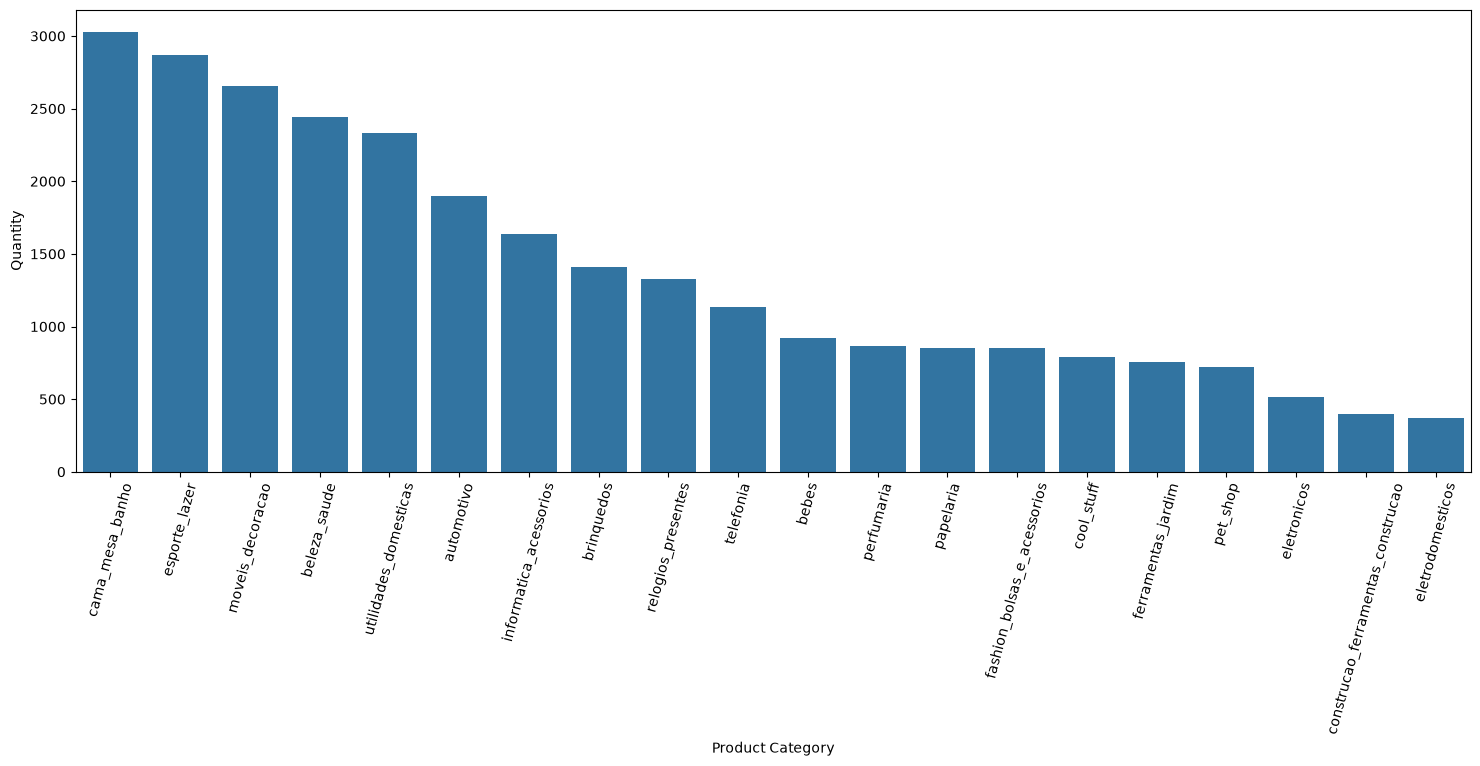

In [36]:
plt.figure(figsize=(18,6))
sns.barplot(x=product_categories.index,
            y=product_categories.values)
plt.xticks(rotation=75)
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.savefig("../../output/charts/products/product_category_count.png",dpi=300)
plt.show()

In [37]:
products["product_id"].nunique()
products["product_id"].duplicated().sum()

np.int64(0)

In [38]:
photo_counts = products["product_photos_qty"].value_counts().sort_index()
photo_counts

product_photos_qty
1.0     16489
2.0      6263
3.0      3860
4.0      2428
5.0      1484
6.0       968
7.0       343
8.0       192
9.0       105
10.0       95
11.0       46
12.0       35
13.0        9
14.0        5
15.0        8
17.0        7
18.0        2
19.0        1
20.0        1
Name: count, dtype: int64

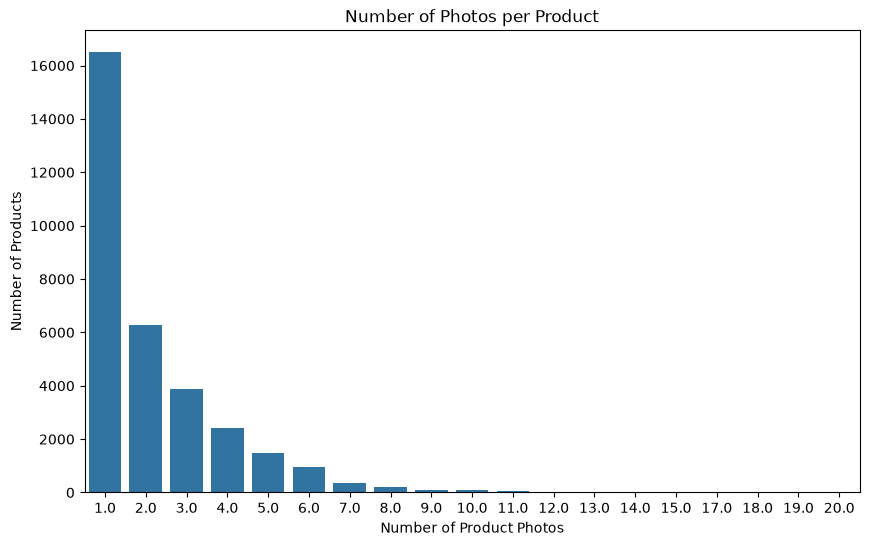

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=photo_counts.index,
    y=photo_counts.values
)
plt.xlabel("Number of Product Photos")
plt.ylabel("Number of Products")
plt.title("Number of Photos per Product")
plt.savefig("../../output/charts/products/product_photos_count.png", dpi=300)
plt.show()

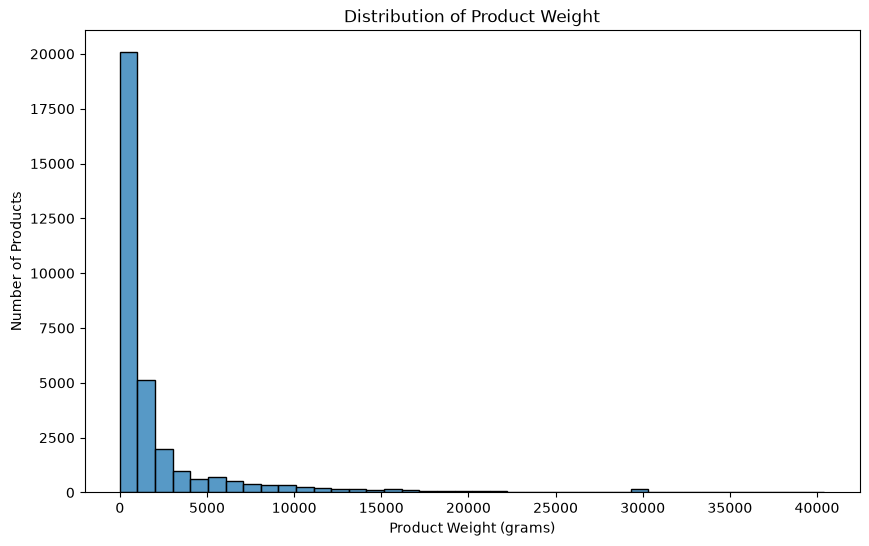

In [40]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=products,
    x="product_weight_g",
    bins=40
)
plt.xlabel("Product Weight (grams)")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Weight")
plt.savefig("../../output/charts/products/product_weight_distribution.png", dpi=300)
plt.show()

In [41]:
product_dimensions = products[
    [
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
]

product_dimensions.describe()

,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000
mean,30.815078,16.937661,23.196728
std,16.914458,13.637554,12.079047
min,7.000000,2.000000,6.000000
25%,18.000000,8.000000,15.000000
50%,25.000000,13.000000,20.000000
75%,38.000000,21.000000,30.000000
max,105.000000,105.000000,118.000000


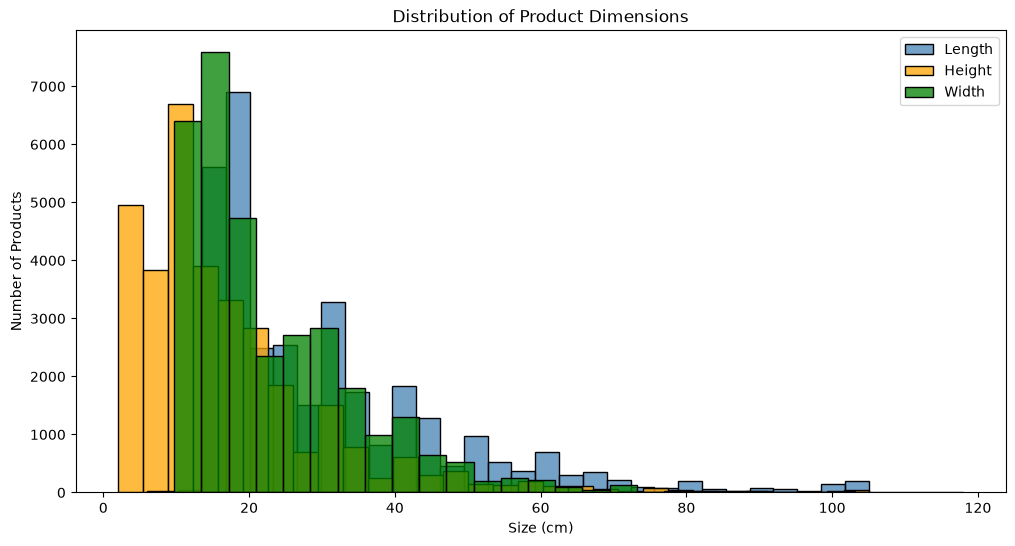

In [42]:
plt.figure(figsize=(12, 6))
sns.histplot(data=products, x="product_length_cm", bins=30, color="steelblue", label="Length")
sns.histplot(data=products, x="product_height_cm", bins=30, color="orange", label="Height")
sns.histplot(data=products, x="product_width_cm", bins=30, color="green", label="Width")
plt.xlabel("Size (cm)")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Dimensions")
plt.legend()
plt.savefig("../../output/charts/products/product_dimensions_distribution.png", dpi=300)
plt.show()

In [43]:
products[["product_weight_g", "product_height_cm"]].corr()

,product_weight_g,product_height_cm
product_weight_g,1.00000,0.56391
product_height_cm,0.56391,1.00000


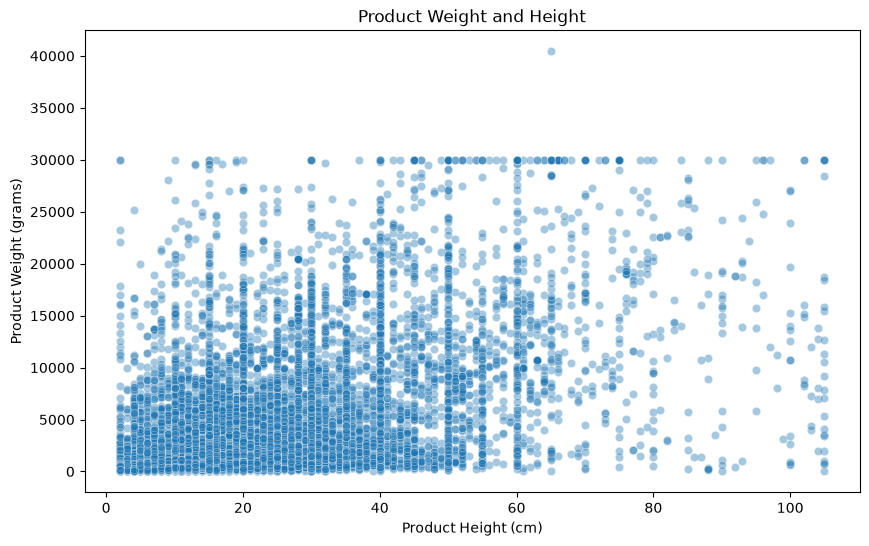

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=products,
    x="product_height_cm",
    y="product_weight_g",
    alpha=0.4
)
plt.xlabel("Product Height (cm)")
plt.ylabel("Product Weight (grams)")
plt.title("Product Weight and Height")
plt.savefig("../../output/charts/products/product_weight_height_scatter.png", dpi=300)
plt.show()

## Key Observations

### 1. Product Data Overview

- The dataset contains information about **32,951 products**.
- Each product has a unique `product_id`, so there are no duplicate product records.
- The dataset includes product category, name length, description length, number of photos, weight, and dimensions.

### 2. Missing Values

- The product category, name length, description length, and photo quantity columns each have **610 missing values**.
- Product weight and dimension columns have very few missing values.
- Missing category and text information may mean that some products were added without complete descriptions.

### 3. Product Categories

- **`cama_mesa_banho`** is the most common product category in the dataset.
- Other frequently occurring categories include **`esporte_lazer`**, **`moveis_decoracao`**, and **`beleza_saude`**.
- The category chart shows that some categories have many more products than others.

### 4. Product Photos

- Most products have **one product photo**.
- Products with two or three photos are also common, but the number decreases as the photo count increases.
- Only a small number of products have many photos.

### 5. Product Weight

- Most products are relatively light, with the largest number weighing less than a few kilograms.
- The distribution is right-skewed because a small number of products are much heavier than the majority.
- The average product weight is approximately **2,276 grams**.

### 6. Product Dimensions

- The average product dimensions are approximately **31 cm in length**, **17 cm in height**, and **23 cm in width**.
- Length, height, and width are mostly concentrated at smaller values, with a few unusually large products.
- These measurements can be useful for understanding storage and shipping requirements.

### 7. Relationship Between Weight and Height

- The correlation between product weight and height is approximately **0.56**.
- This suggests a moderate positive relationship: taller products tend to be heavier.
- However, the scatter plot shows many different weights at similar heights, so height alone does not determine product weight.

### Overall Insight

Overall, the product catalog contains many different categories, but product availability is concentrated in a few popular categories. Most products have only one or two photos and are relatively light. Product dimensions are generally small, while a few heavy or oversized products create a wide range in the data. Some products have missing category or descriptive information, which may need to be handled before further analysis or modeling.